In [1]:
import pickle
import numpy as np
import pandas as pd
import hicona as hicona
import graph_tool.all as gt
import polars as pl

### 1) Compute EIS score

In [ ]:
file='GSM8533704_deltaGAP1_G1s10h'
REGION='chr17:50000-73400000'
COOLER=f'{file}.cool::resolutions/100000'

handle = hicona.HiconaCooler(COOLER)
table = handle.get_pixel_table(REGION)


state=table.add_clustering(
    REGION,  # Do NOT forget or it stalls indefinitely
    marginals='pixels',  # or "bins" or "pixels", default is "no"
    seed=42,  # Default
    logging_level="INFO",  # Default
)

print(state.entropy())


### 2) Plotting

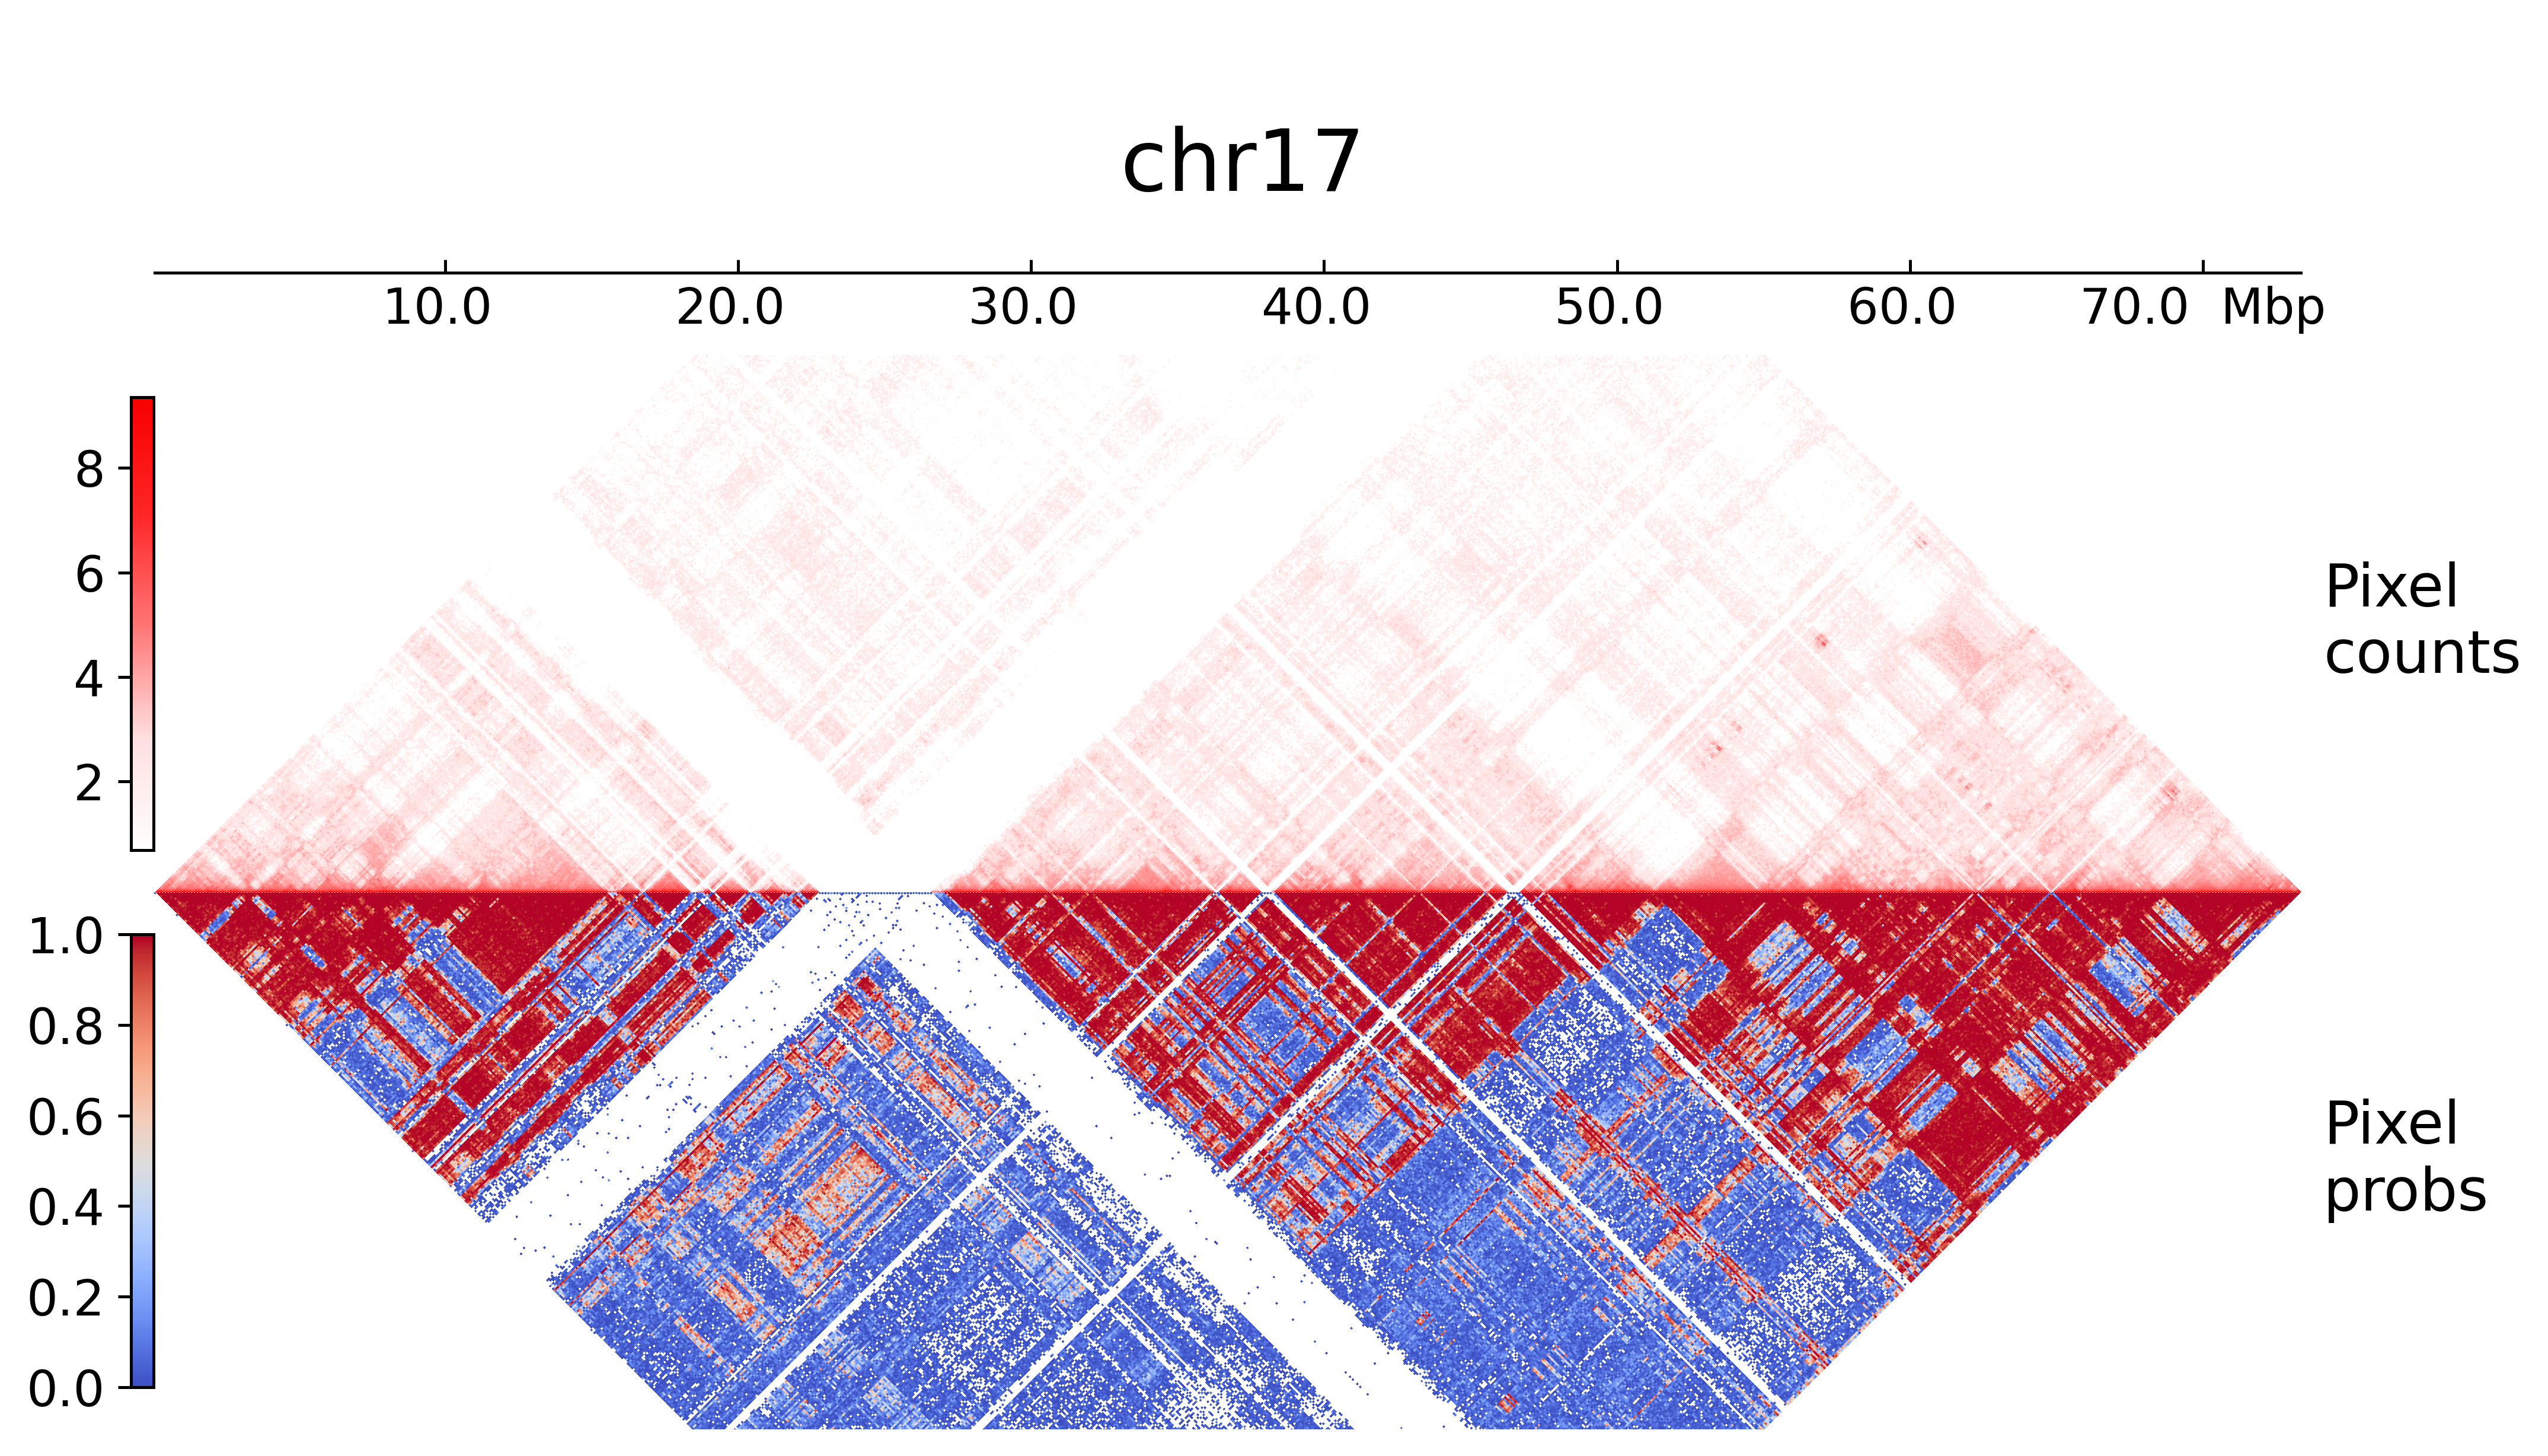

In [6]:
hicona.plotting.plot_comparison(
    table,
    region=REGION,
    value_cols=['count','pix_prob'])

In [ ]:
df=table.get_